<>:34: SyntaxWarning: invalid escape sequence '\ '
<>:34: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipykernel_2600/3805811913.py:34: SyntaxWarning: invalid escape sequence '\ '
  print("\ nEach tree's prediction in bagging:")
/home/codespace/.local/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/home/codespace/.local/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but BaggingClassifier was fitted with feature names
  warnings.warn(
/home/codespace/.local/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/home/codespace/.local/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but Ba

Prediction (Single Decision Tree): 0
Prediction (Bagging): 1
\ nEach tree's prediction in bagging:
Tree 1 predicts: 0
Tree 2 predicts: 1
Tree 3 predicts: 1


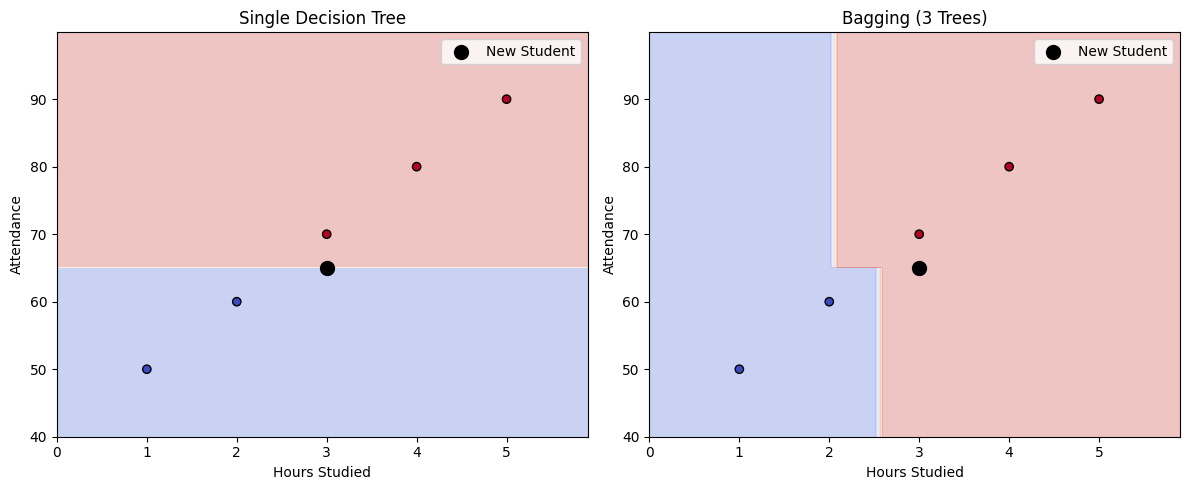

"Output -\nPrediction (Single Decision Tree): 0\nPrediction (Bagging): 1\nEach tree's prediction in bagging:\nTree 1 predicts: 0\nTree 2 predicts: 1\nTree 3 predicts: 1\n"

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
# Simple dataset
data = {
   'Hours_Studied': [2, 4, 1, 3, 5],
   'Attendance':    [60, 80, 50, 70, 90],
   'Pass':          [0, 1, 0, 1, 1]
}
df = pd.DataFrame(data)
# Features and target
X = df[['Hours_Studied', 'Attendance']]
y = df['Pass']
# 🎯 New student
new_student = [[3, 65]]
# 🌳 Single Decision Tree
tree = DecisionTreeClassifier(random_state=0)
tree.fit(X, y)
pred_tree = tree.predict(new_student)[0]
# 🪄 Bagging with 3 trees
bagging = BaggingClassifier(
   estimator=DecisionTreeClassifier(),
   n_estimators=3,
   bootstrap=True,
   random_state=0
)
bagging.fit(X, y)
pred_bag = bagging.predict(new_student)[0]
# Print predictions
print("Prediction (Single Decision Tree):", pred_tree)
print("Prediction (Bagging):", pred_bag)
print("\ nEach tree's prediction in bagging:")
for i, est in enumerate(bagging.estimators_):
   print(f"Tree {i+1} predicts: {est.predict(new_student)[0]}")
h = 0.1  # step size for mesh

x_min, x_max = X['Hours_Studied'].min() - 1, X['Hours_Studied'].max() + 1
y_min, y_max = X['Attendance'].min() - 10, X['Attendance'].max() + 10
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
mesh_points = np.c_[xx.ravel(), yy.ravel()]
# Predict for each model
Z_tree = tree.predict(mesh_points).reshape(xx.shape)
Z_bag = bagging.predict(mesh_points).reshape(xx.shape)
# Create subplots
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
# Plot Decision Tree
axs[0].contourf(xx, yy, Z_tree, cmap=plt.cm.coolwarm, alpha=0.3)
axs[0].scatter(X['Hours_Studied'], X['Attendance'], c=y, cmap=plt.cm.coolwarm, edgecolors='k')
axs[0].scatter(new_student[0][0], new_student[0][1], color='black', s=100, label='New Student')
axs[0].set_title("Single Decision Tree")
axs[0].set_xlabel("Hours Studied")
axs[0].set_ylabel("Attendance")
axs[0].legend()
# Plot Bagging
axs[1].contourf(xx, yy, Z_bag, cmap=plt.cm.coolwarm, alpha=0.3)
axs[1].scatter(X['Hours_Studied'], X['Attendance'], c=y, cmap=plt.cm.coolwarm, edgecolors='k')
axs[1].scatter(new_student[0][0], new_student[0][1], color='black', s=100, label='New Student')
axs[1].set_title("Bagging (3 Trees)")
axs[1].set_xlabel("Hours Studied")
axs[1].set_ylabel("Attendance")
axs[1].legend()
plt.tight_layout()
plt.show()
'''Output -
Prediction (Single Decision Tree): 0
Prediction (Bagging): 1
Each tree's prediction in bagging:
Tree 1 predicts: 0
Tree 2 predicts: 1
Tree 3 predicts: 1
'''